In [37]:
from cProfile import label

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import pylab as pl
import seaborn as sns
from matplotlib.lines import lineStyles
from matplotlib.pyplot import title
from scipy.spatial.transform import rotation

In [38]:
df = pd.read_csv('data/cleanedDataset.csv')
df.head()
df1 = pd.read_csv('data/rawData.csv')

In [39]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'hasCabin', 'Embarked_C',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

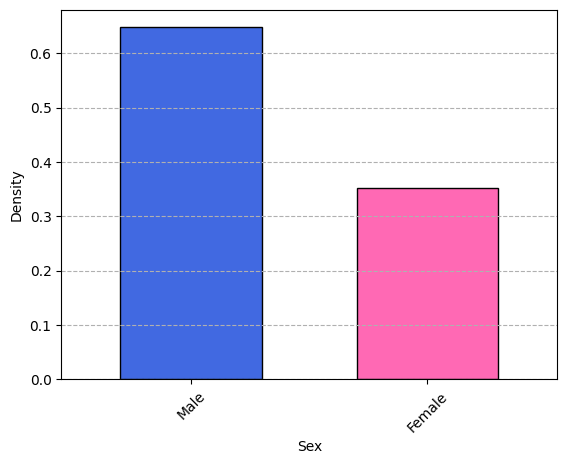

In [40]:
gender = (df['Sex'].value_counts()/df['Sex'].value_counts().sum()).sort_index()

gender.plot(kind='bar', color=['royalblue', 'hotpink'], edgecolor='black', width=0.6)
plt.xticks([0, 1], ['Male', 'Female'], rotation=45)
plt.grid(axis='y', linestyle='--')
plt.ylabel('Density')
plt.show()

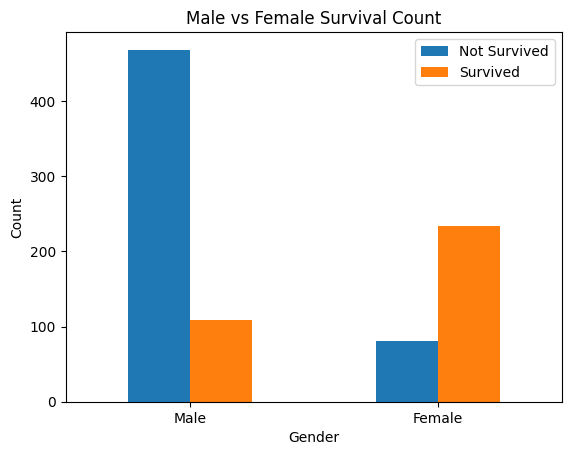

In [6]:
sex_survived = df.groupby(['Sex', 'Survived']).size().unstack()

sex_survived.plot(kind='bar')

plt.title('Male vs Female Survival Count')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.xticks([0, 1], ['Male', 'Female'],rotation=0)
plt.legend(['Not Survived', 'Survived'])

plt.show()

In [41]:
sex_survived

Survived,0,1
Sex,,
0,468,109
1,81,233


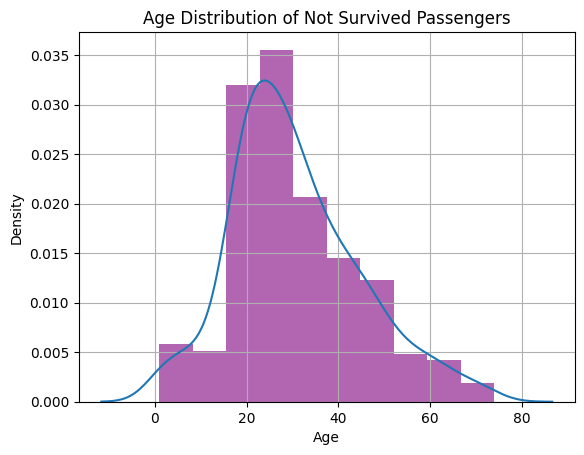

In [42]:
not_survived_age = df1[df1['Survived'] == 0]['Age']

not_survived_age.hist(bins=10, color='purple', density=True, alpha=0.6)

sns.kdeplot(not_survived_age)

plt.title('Age Distribution of Not Survived Passengers')
plt.xlabel('Age')
plt.ylabel('Density')

plt.show()

In [43]:
not_survived_age.skew()

np.float64(0.5855837826738851)

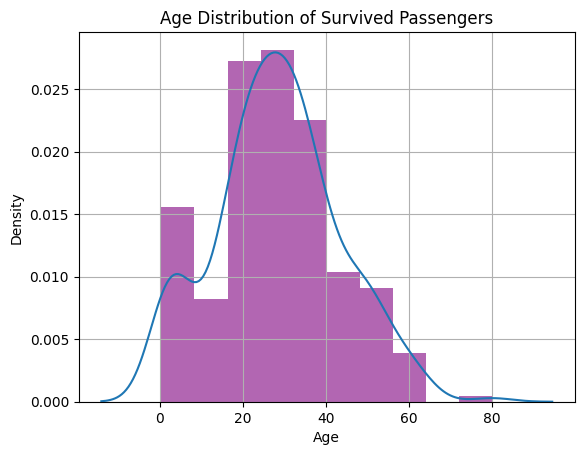

In [44]:
survived_age = df1[df1['Survived'] == 1]['Age']

survived_age.hist(bins=10, color='purple', density=True, alpha=0.6)

sns.kdeplot(survived_age)

plt.title('Age Distribution of Survived Passengers')
plt.xlabel('Age')
plt.ylabel('Density')

plt.show()

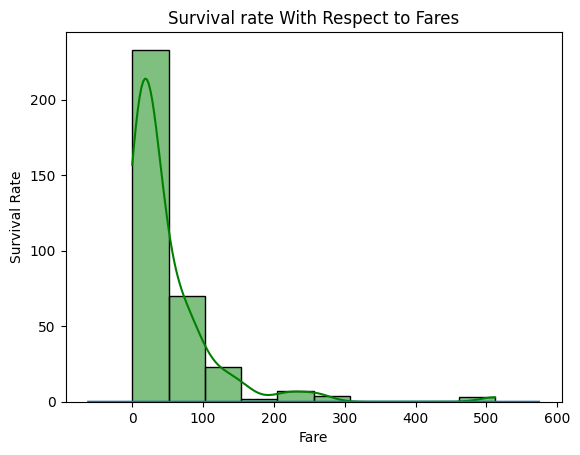

In [45]:
survived_fare = df1[df1['Survived'] == 1]['Fare']

sns.histplot(survived_fare, bins=10, kde=True, color='green')
plt.title('Survival rate With Respect to Fares')
plt.xlabel('Fare')
sns.kdeplot(survived_fare)
plt.ylabel('Survival Rate')
plt.show()

In [46]:
survived_fare.skew()

np.float64(3.8627793799441936)

In [47]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'hasCabin', 'Embarked_C',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [48]:
cols = ['Sex', 'Age', 'Fare', 'hasCabin']
for col in cols:
    print(f"Correlation of Survived with {col} is {np.corrcoef(df[col], df['Survived'])[0][1]}")

Correlation of Survived with Sex is 0.5433513806577546
Correlation of Survived with Age is -0.06980851528714307
Correlation of Survived with Fare is 0.2573065223849622
Correlation of Survived with hasCabin is 0.3169115231122957


In [49]:
cols = ['Embarked_C', 'Embarked_Q', 'Embarked_S']
corr = 0
for col in cols:
    print(col)
    print(np.corrcoef(df[col], df['Survived'])[0][1])


Embarked_C
0.16824043121823296
Embarked_Q
0.0036503826839719864
Embarked_S
-0.15566027340439326


In [50]:
embarked_table = pd.crosstab(df1['Embarked'], df1['Survived'])
embarked_table.sum()

Survived
0    549
1    340
dtype: int64

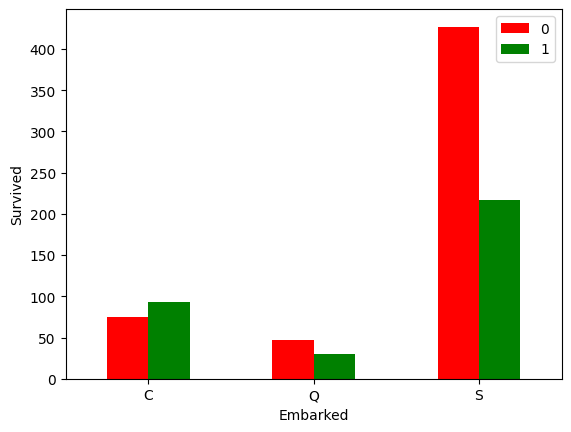

In [51]:
embarked_table.plot(kind='bar', color=['red', 'green'])
plt.xlabel('Embarked')
plt.ylabel('Survived')
plt.legend()
plt.xticks(rotation=0)
plt.show()

In [52]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'hasCabin', 'Embarked_C',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [53]:
hascabin_df = pd.crosstab(df['hasCabin'], df['Survived'])
hascabin_df

Survived,0,1
hasCabin,,
0,481,206
1,68,136


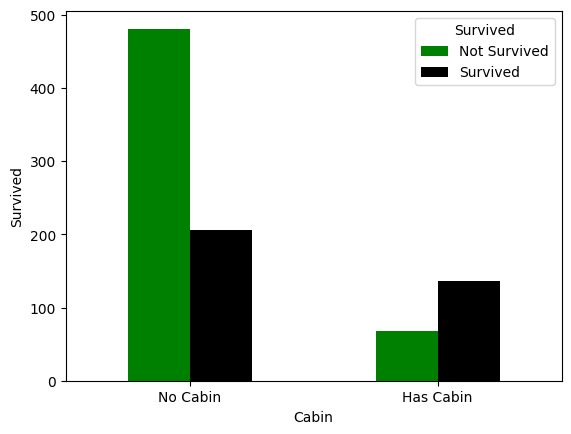

In [54]:
hascabin_df.plot(kind='bar', color=['green', 'black'])
plt.xlabel('Cabin')
plt.ylabel('Survived')
plt.xticks([0, 1], ['No Cabin', 'Has Cabin'], rotation=0)
plt.legend(['Not Survived', 'Survived'], title='Survived')
plt.show()

In [55]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'hasCabin', 'Embarked_C',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [56]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [57]:
pclass_survived = pd.crosstab(df['Pclass'], df['Survived'])
pclass_survived

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


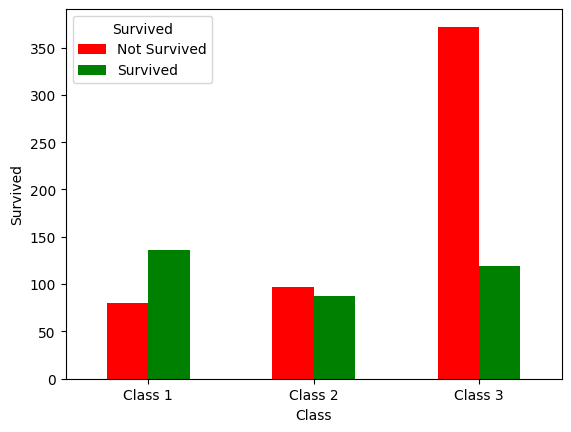

In [58]:
pclass_survived.plot(kind='bar', color=['red', 'green'])
plt.xticks([0, 1, 2], ['Class 1', 'Class 2', 'Class 3'], rotation=0)
plt.xlabel('Class')
plt.ylabel('Survived')
plt.legend(['Not Survived', 'Survived'], title = 'Survived')
plt.show()

In [59]:
class_counts = df['Pclass'].value_counts().sort_values().values
class_categories = df['Pclass'].value_counts().sort_values().index
print(class_counts)
print(class_categories)

[184 216 491]
Index([2, 1, 3], dtype='int64', name='Pclass')


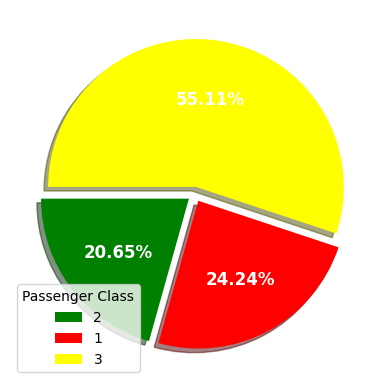

In [60]:
explode = [0.05, 0.05, 0.05]
cat_color = ['green', 'red', 'yellow']
plt.pie(class_counts, labels=class_categories, explode=explode, startangle=180, colors=cat_color, shadow=True
,       autopct='%2.2f%%',  textprops={
        'color': 'white',
        'fontsize': 12,
        'fontweight': 'bold'})
plt.legend(title='Passenger Class')
plt.show()

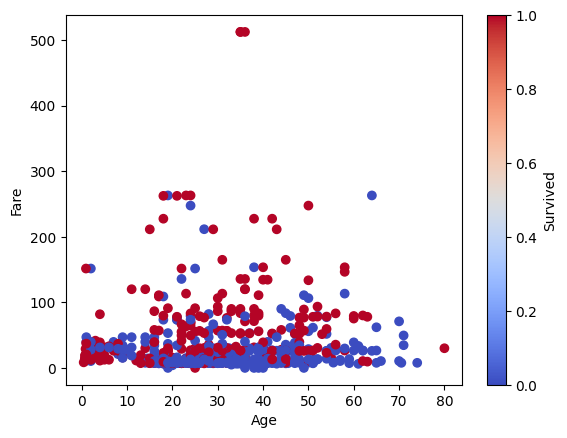

In [61]:
plt.scatter(df1['Age'], df1['Fare'], c = df['Survived'], cmap='coolwarm')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.colorbar(label='Survived')
plt.show()

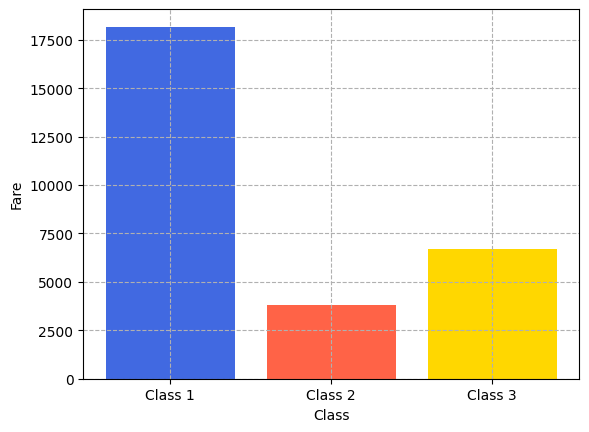

In [62]:
fare_class = df1.groupby('Pclass')['Fare'].sum().sort_index()

plt.bar(fare_class.index, fare_class.values, color=['royalblue', 'tomato', 'gold'])
plt.xticks(fare_class.index, labels=['Class 1', 'Class 2', 'Class 3'])
plt.xlabel('Class')
plt.ylabel('Fare')
plt.grid(True, linestyle='--')
plt.show()


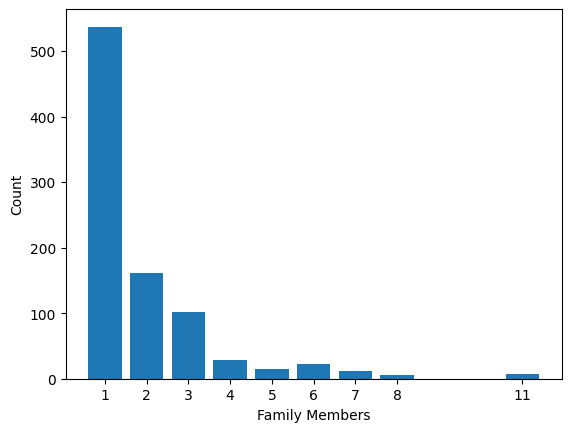

In [63]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
family = df['FamilySize'].value_counts().sort_index()

plt.bar(family.index, family.values)
plt.xlabel('Family Members')
plt.ylabel('Count')
plt.xticks(family.index)
plt.show()

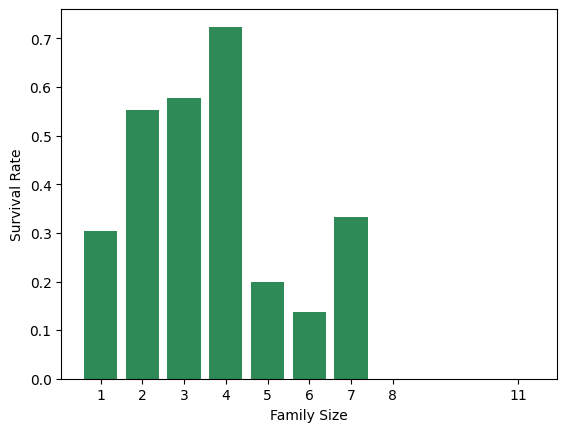

In [64]:
family_survival = df.groupby('FamilySize')['Survived'].mean()

plt.bar(family_survival.index, family_survival.values, color='seagreen')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.xticks(family.index)
plt.show()

In [65]:
mean = df1.mean(numeric_only=True)
median = df1.median(numeric_only=True)
mode = df1.mode().iloc[0]

stats = pd.DataFrame({
    'Mean': mean,
    'Median': median,
    'Mode': mode
})

print(stats)

                   Mean    Median                 Mode
Age           29.699118   28.0000                 24.0
Cabin               NaN       NaN              B96 B98
Embarked            NaN       NaN                    S
Fare          32.204208   14.4542                 8.05
Name                NaN       NaN  Abbing, Mr. Anthony
Parch          0.381594    0.0000                  0.0
PassengerId  446.000000  446.0000                    1
Pclass         2.308642    3.0000                  3.0
Sex                 NaN       NaN                 male
SibSp          0.523008    0.0000                  0.0
Survived       0.383838    0.0000                  0.0
Ticket              NaN       NaN                 1601


In [66]:
df1['FamilySize'] = df1['SibSp'] + df1['Parch'] + 1

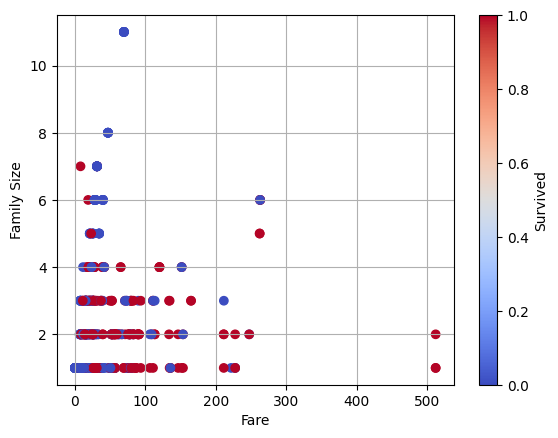

In [67]:
plt.scatter(df1['Fare'], df1['FamilySize'], c = df['Survived'], cmap='coolwarm')
plt.xlabel('Fare')
plt.colorbar(label='Survived')
plt.ylabel('Family Size')
plt.grid(True)
plt.show()

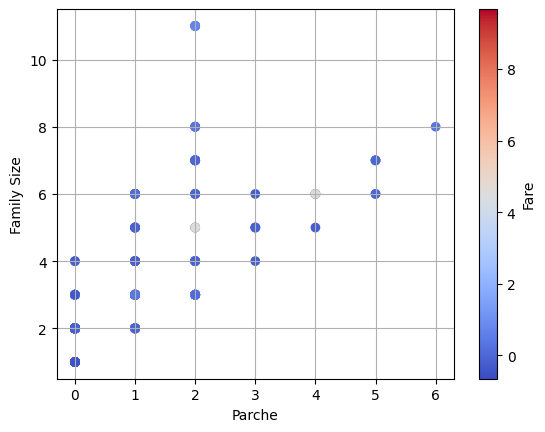

In [71]:
plt.scatter(df['Parch'], df['FamilySize'], c = df['Fare'], cmap='coolwarm')
plt.xlabel('Parche')
plt.colorbar(label='Fare')
plt.ylabel('Family Size')
plt.grid(True)
plt.show()

In [68]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'hasCabin', 'Embarked_C',
       'Embarked_Q', 'Embarked_S', 'FamilySize'],
      dtype='object')

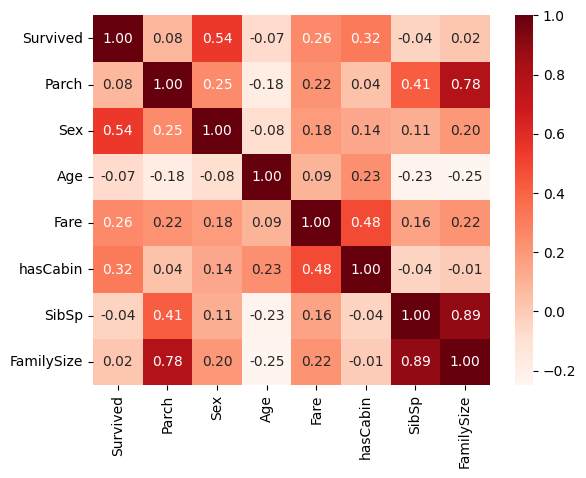

In [69]:
cols = ['Survived', 'Parch', 'Sex', 'Age', 'Fare', 'hasCabin', 'SibSp', 'FamilySize']
df_subset = df[cols]
corr = df_subset.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Reds')
plt.show()

In [70]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, explorative=True)

profile.to_file("report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 13.78it/s]
